# 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

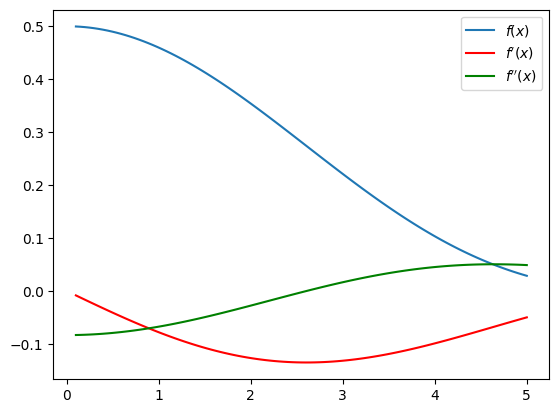

In [30]:
# Firstly, defining the function & its derivatives and plotting
def f(x):
    return (1 - np.cos(x)) / x**2  # using numpy cos ensures I can pass an array as an input

def fprime(x):
    return (2*np.cos(x) + x * np.sin(x) - 2) / x**3

def fprimeprime(x):
    return ((x**2 - 6) * np.cos(x) - 4*x * np.sin(x) + 6) / x**4

x = np.linspace(0.1, 5, 101)
plt.plot(x,f(x),label="$f(x)$")  
plt.plot(x,fprime(x),label="$f'(x)$",color='r')
plt.plot(x,fprimeprime(x),label="$f''(x)$",color='g')
plt.legend()

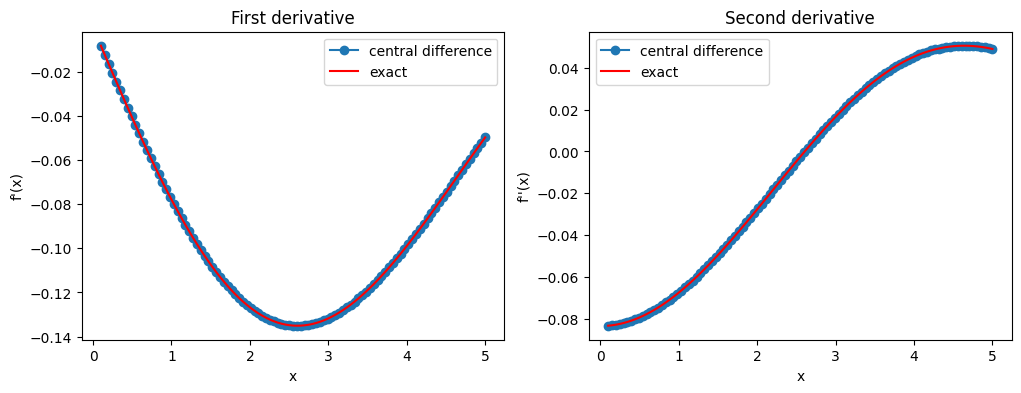

In [36]:
# defining central difference functions for the first and second derivatives
def fprime_cd(x, h):
    return (f(x+h) - f(x-h)) / (2*h)

def fprimeprime_cd(x, h):
    return (f(x+h) + f(x-h) - 2*f(x)) / h**2

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].set_title("First derivative")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f'(x)")
axes[0].plot(x,fprime_cd(x, 0.001),marker='o',label='central difference')
axes[0].plot(x,fprime(x),color='r',label='exact')
axes[0].legend()

axes[1].set_title("Second derivative")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f''(x)")
axes[1].plot(x,fprimeprime_cd(x, 0.001),marker='o',label='central difference')
axes[1].plot(x,fprimeprime(x),color='r',label='exact')
axes[1].legend()

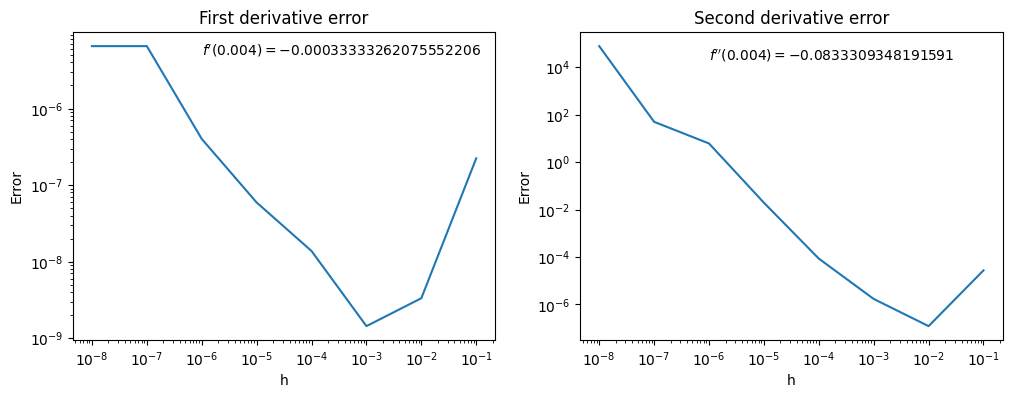

In [50]:
# compute error for each derivative and plot
h_vals = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
fprime_errors = []
fprimeprime_errors = []

for hval in h_vals:
    error1 = np.abs(fprime_cd(0.004, hval) - fprime(0.004))
    error2 = np.abs(fprimeprime_cd(0.004, hval) - fprimeprime(0.004))
    fprime_errors.append(error1)
    fprimeprime_errors.append(error2)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].set_title("First derivative error")
axes[0].set_xlabel("h")
axes[0].set_ylabel("Error")
axes[0].text(1e-6,5e-6,f"$f'(0.004)={fprime_cd(0.004,0.001)}$")
axes[0].loglog(h_vals,fprime_errors)

axes[1].set_title("Second derivative error")
axes[1].set_xlabel("h")
axes[1].set_ylabel("Error")
axes[1].text(1e-6,2e4,f"$f''(0.004)={fprimeprime_cd(0.004,0.001)}$")
axes[1].loglog(h_vals,fprimeprime_errors)